In [1]:
from sklearn import datasets

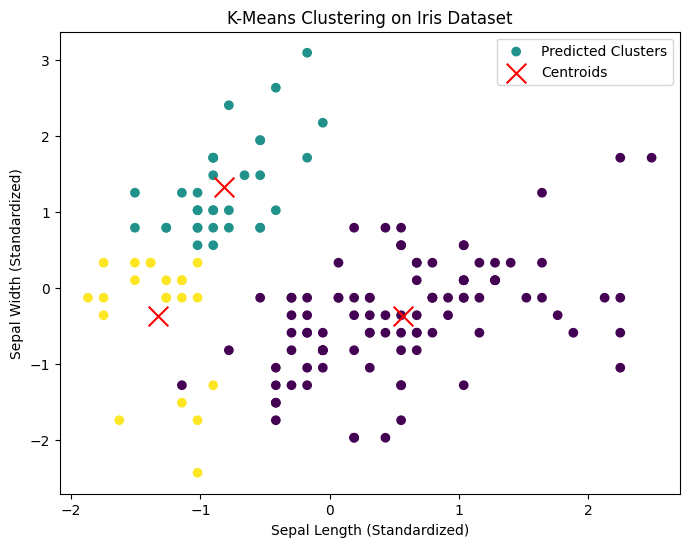

In [3]:
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features
y_true = iris.target  # True labels (for comparison)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

# Visualize results (using first two features)
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis', label='Predicted Clusters')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='x', label='Centroids')
plt.xlabel('Sepal Length (Standardized)')
plt.ylabel('Sepal Width (Standardized)')
plt.title('K-Means Clustering on Iris Dataset')
plt.legend()
plt.show()   

In [7]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [12]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [13]:
import numpy as np

In [20]:
def distance_euclidean(src, dest):
    return np.sum((src - dest) ** 2) ** .5

In [25]:
def distance_taxicab(src, dest):
    return np.sum(np.abs(src - dest))

In [26]:
src, dest = np.array([1,2]), np.array([2,3])

In [27]:
distance_euclidean(src, dest)

np.float64(1.4142135623730951)

In [28]:
distance_taxicab(src, dest)

np.int64(2)

In [33]:
def distance_minkowski(src, dest, p):
    return np.sum(np.abs(src - dest) ** p) ** (1 / p)

In [34]:
a = distance_minkowski(src, dest, 1) # taxicab
b = distance_minkowski(src, dest, 2) # euclidean
a, b

(np.float64(2.0), np.float64(1.4142135623730951))

In [119]:
def knn_predict(target, X, y, k, p=2):
    logits = np.sum(np.abs(target - X) ** p, 1) ** (1 / p)
    indices = logits.argsort()[:k]
    return np.bincount(y[indices]).argmax()

In [120]:
result = knn_predict(iris.data[140], iris.data[10:], iris.target, 5)
result

np.int64(2)